    VAE's

    1. Why do we need to Organize Latent Space.
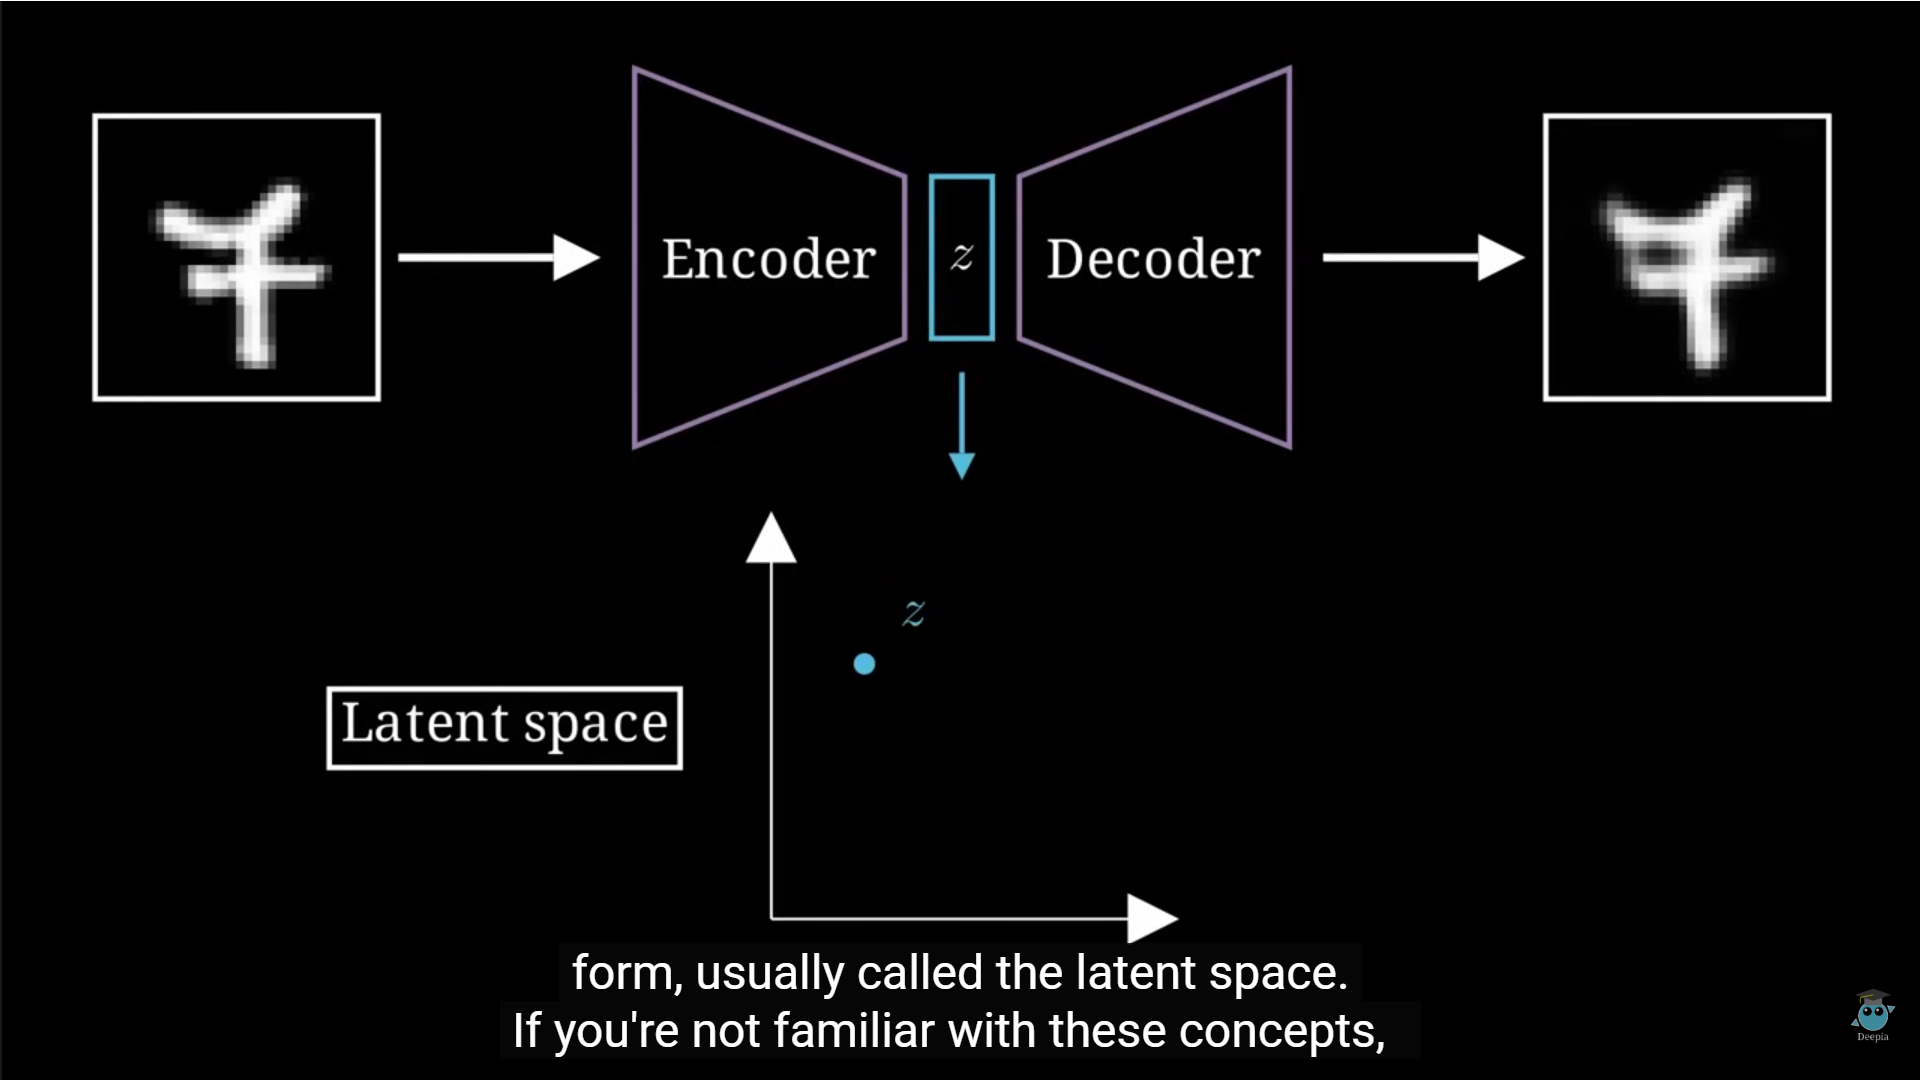
        
        
        => Randomly sampling points from latent space and  decoding this sample - will generate a new image. But In most cases  this will not produce useful results, because latent space is disorganized and irregular. So it will not be able to produce meaningful decoded images.
        
        => Another approach is -> take an encoded image and then sample points that are in the neighborhood of its representation. And these neighbor sample points when decoded will generate new Image. But still it will not produce useful results, because latent space is poorly structured that even nearby points often do not correspond to meaningful variations of the original image. 
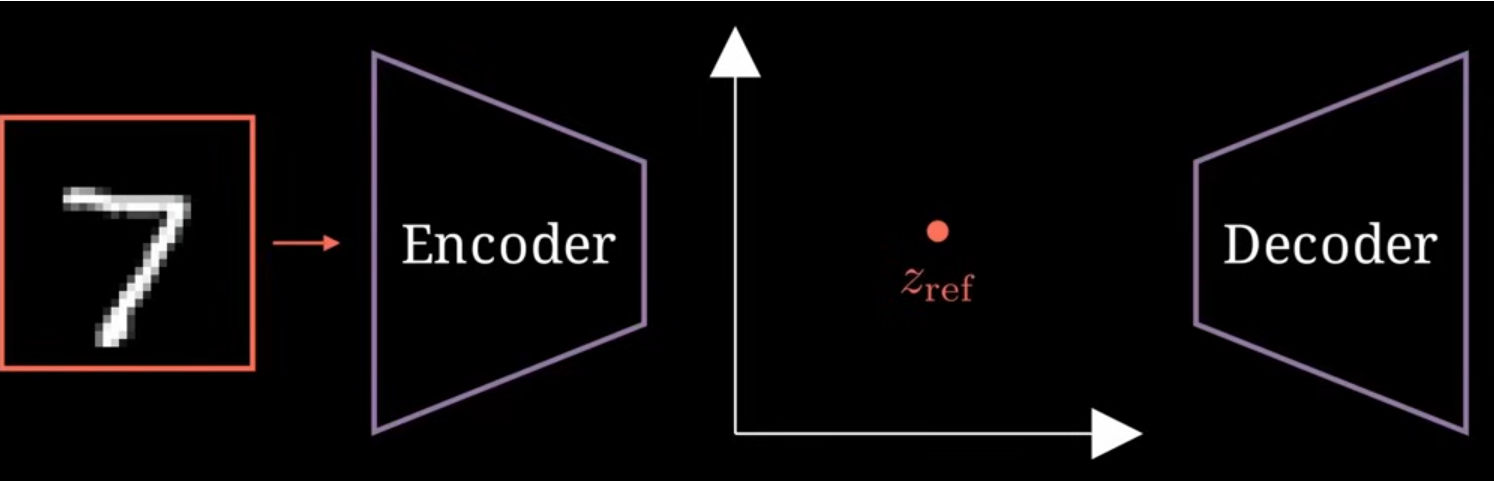
        
        
        => SO we need to Organize Latent Space
        
    2. -Diederik  Kingma  -  introduced (in paper - Auto encoding variational Bayes).
        a.  He is also the mind behind Adam Optimizer.
    
    3. Introduction to bayesian stats.
        a. Probabjuility density function & Expectation.
            § Say we have random Variable X => which can take any  value between,  0 to 10.
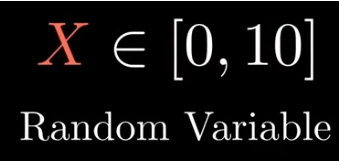
            § Say we pick sample a x from X => we call it as Sampling
                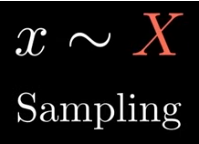
            § Probability density function of x  = p(x)
                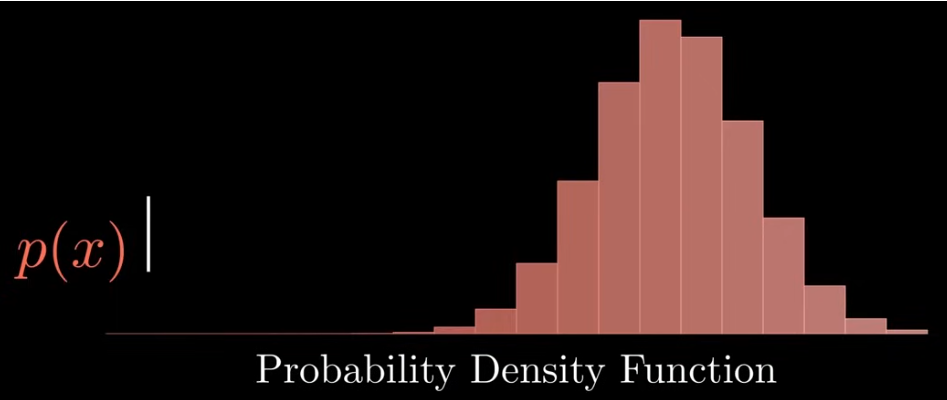
                
                
            § Expectation E[X] => average value you can expect when sampling from X. It can be computed using Integral of Probability density function.
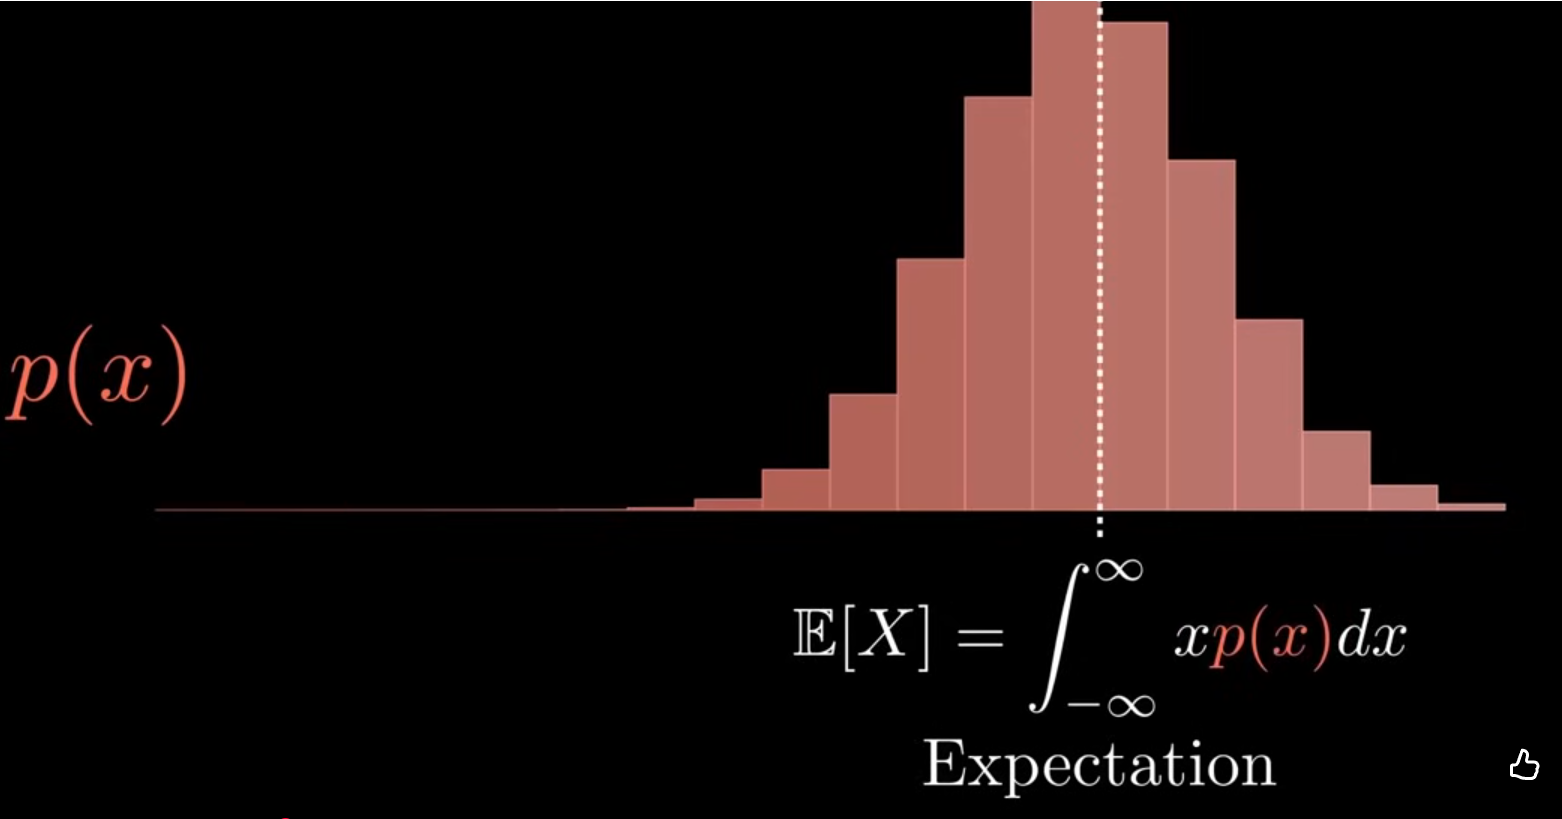
            
            
        b. Joint Probability distribution.
            i. Lets consider 2 random variables - X and Z. Below represents Joint probability distribution of X and Z occuring together.
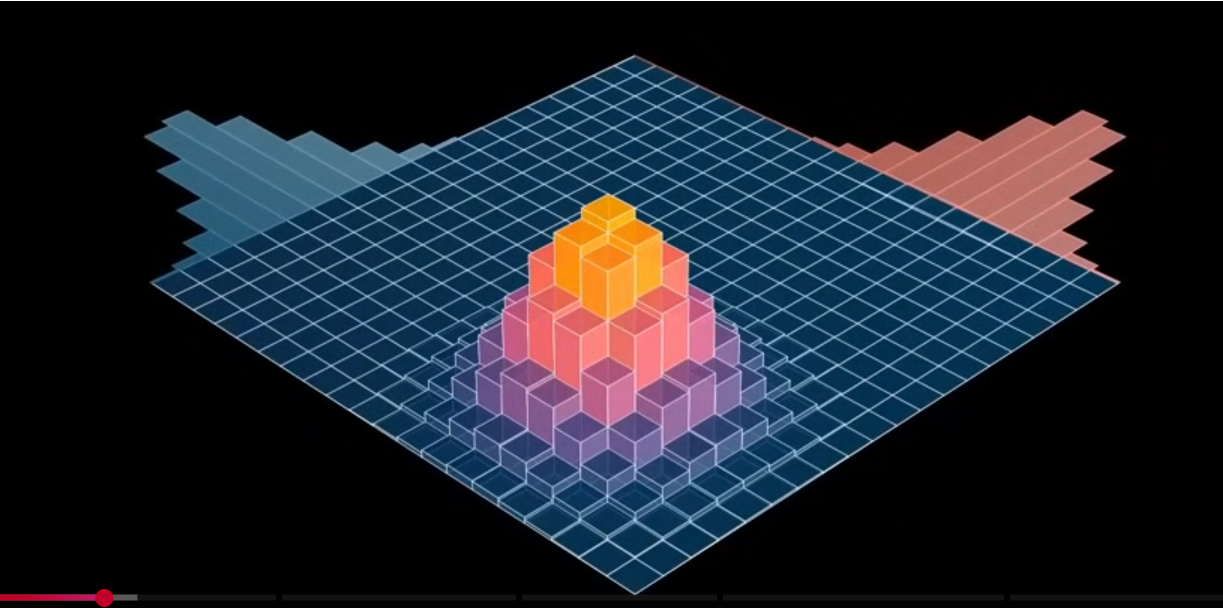
                
        c. Marginal Probability distribution will be p(x) and p(x) - separate densities. We can compute each of the marginal distributions, using below formulae.

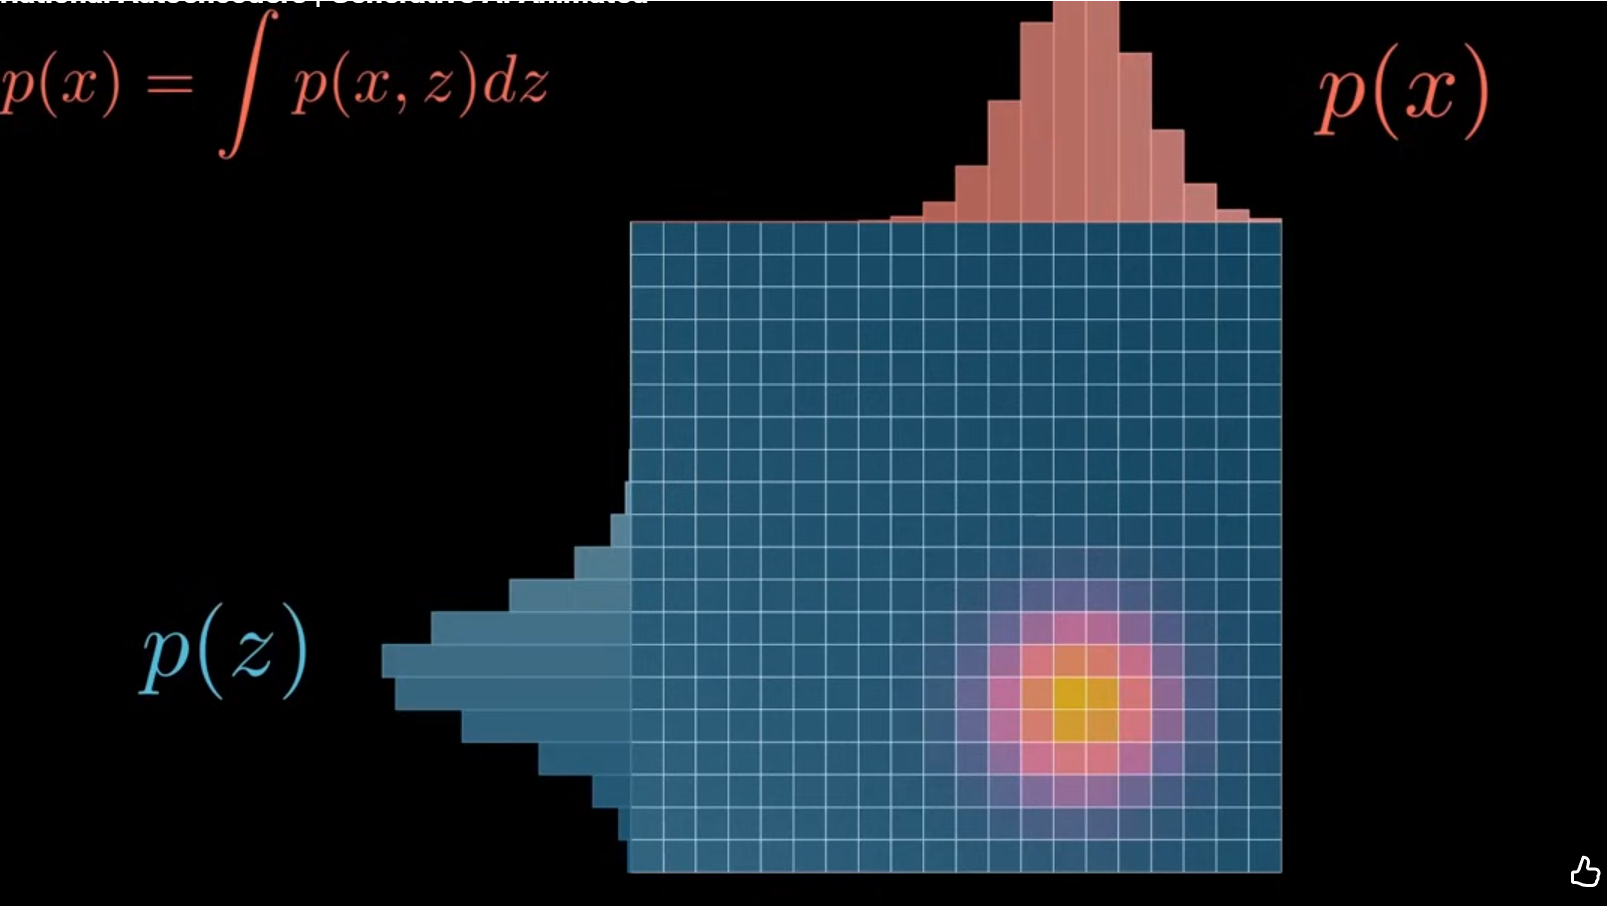
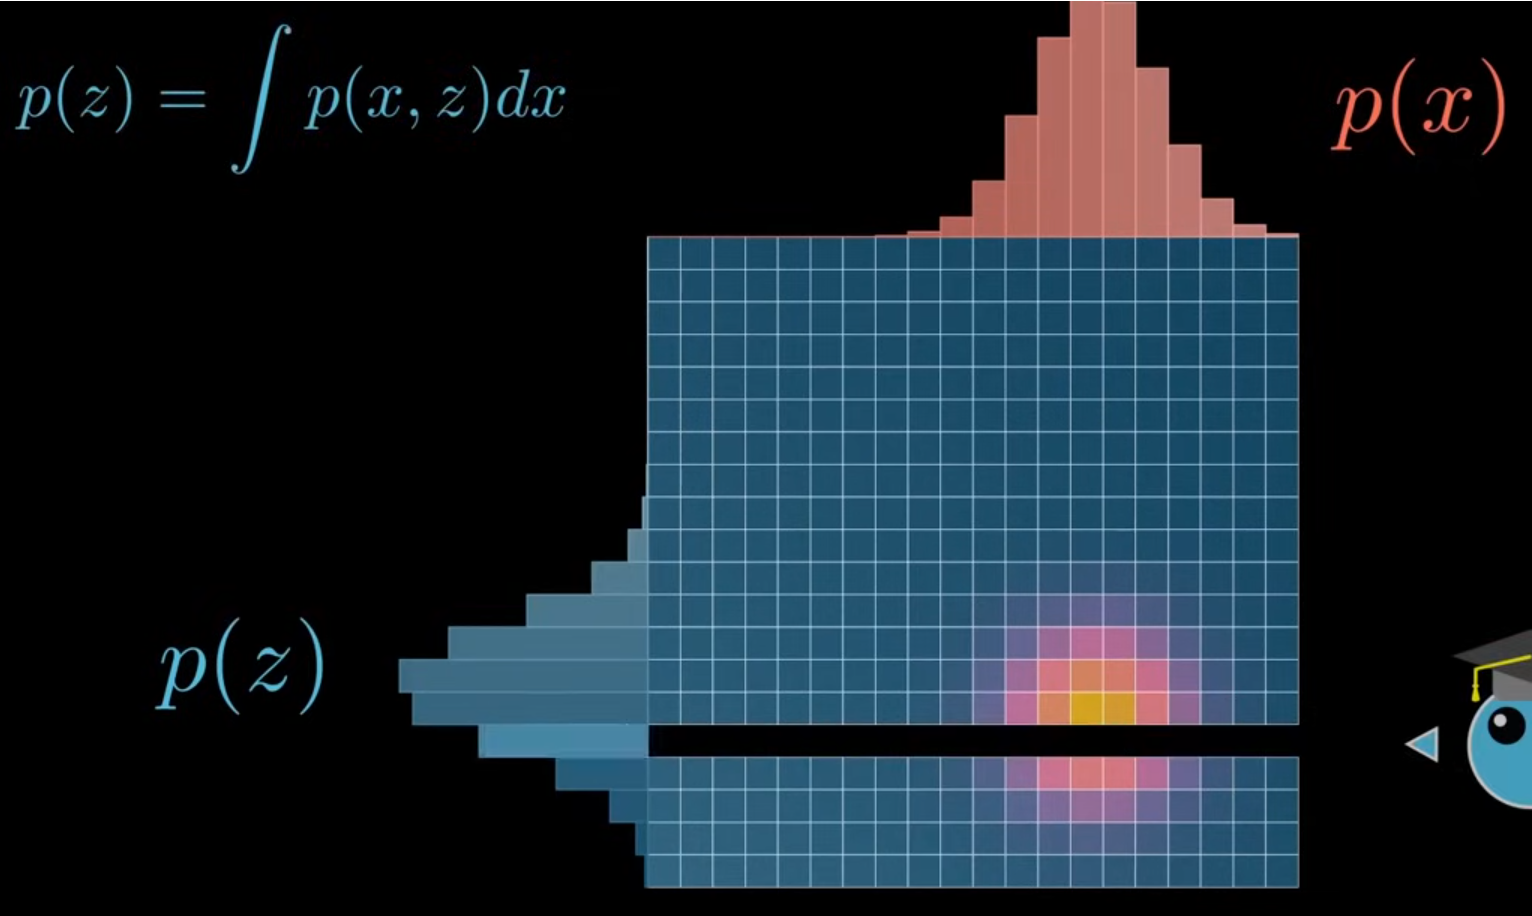
            
        
        d.  Conditional Probability
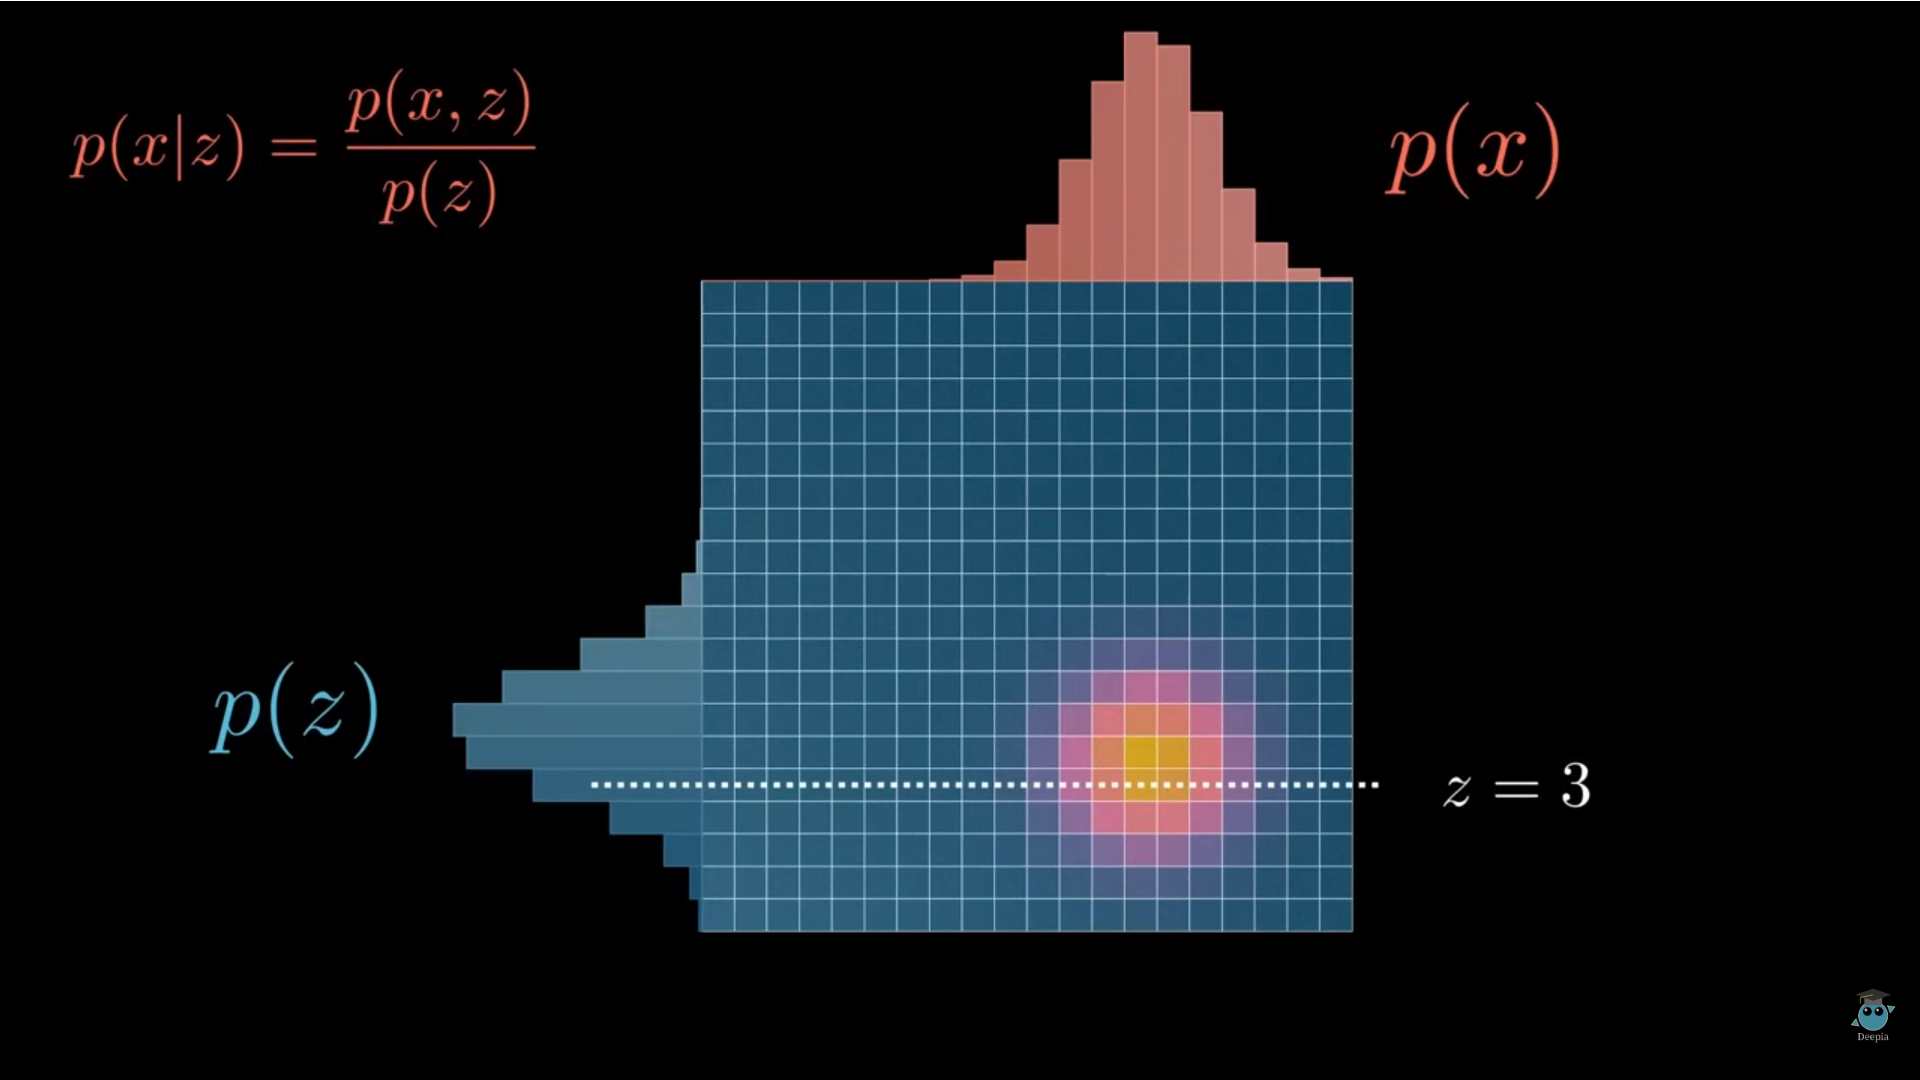
        Similarly 
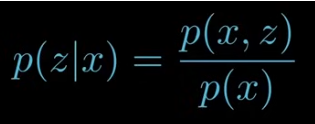


    1. VAE's
        a. Our goal is to  generate new data from a  given data distribution p(x) which represents our dataset - for example images. 
        b. But we do not know the exact shape and property of p(x), we only have access to some samples,  in this p(x) i.e images from our training split.
        c. So we introduce p(z) -> called as Latent distribution - that capture core features of the data.
        d. p(x) <--> p(z)  => needs mapping to connect them. 
            i. So this will be p(z|x) called as  posterior distribution.  It gives us the probability Latent vector Z was generated by a particular image x. 
            ii. 2nd mapping is the likelihood distribution which given a latent z tells us probability  of reconstructing image x from  it.
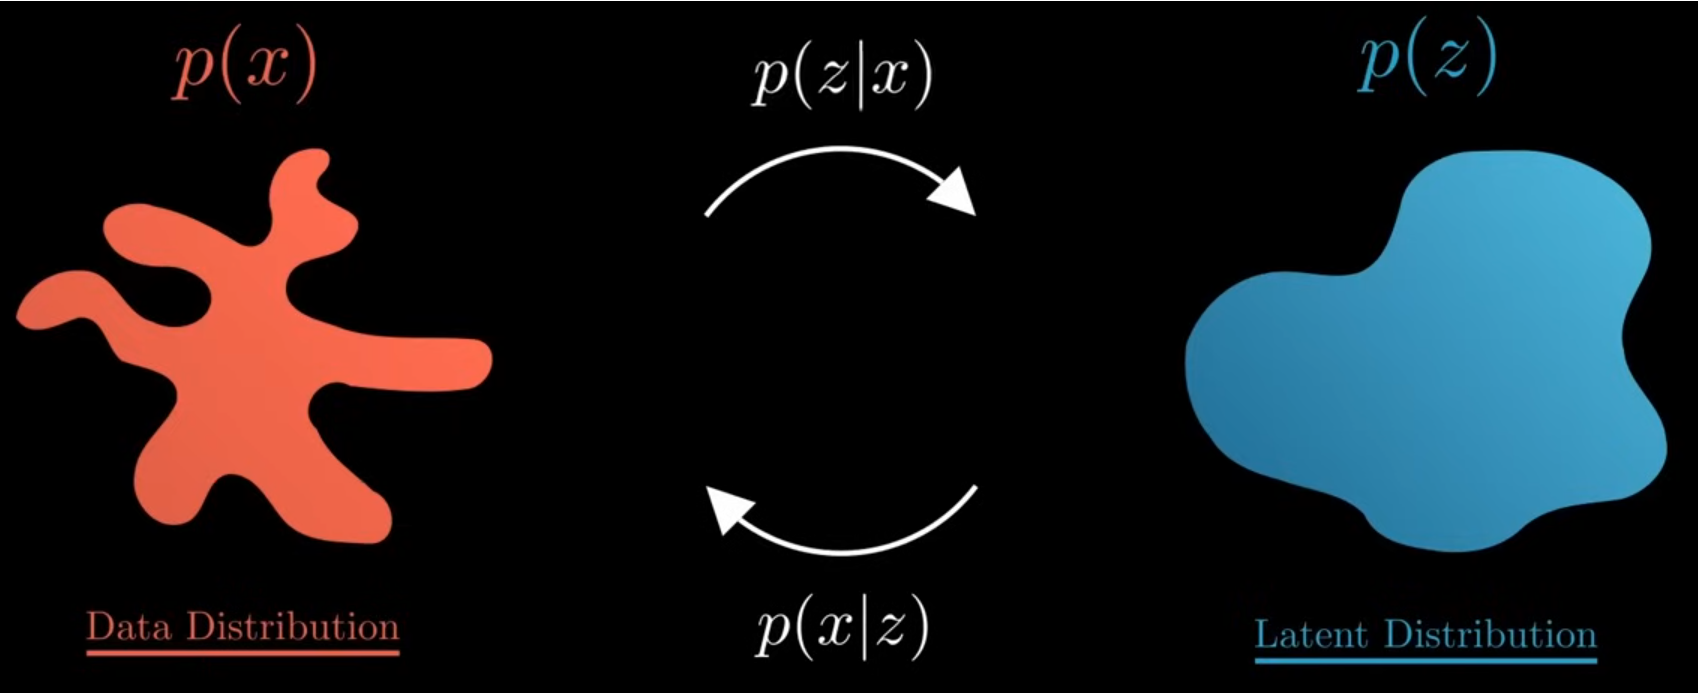
            
        e. If you can sample Latent vectors from posterior distribution, those latents are likely to have been generated by images(our training set of images) which is our original data distribution p(x). So if we can reconstruct these latent vectors back into images, we will effectively generate new samples from our original data distribution.
        f. ei
        g. But => we do not know exact form of p(z) which makes all the computations intractable.
            i. To solve this we  assume  Latent distribution as Normal distribution.  This will allow us to compute the likelihood p(x|z).
                Normal distributed Laten space is represented by p(z) = N(0,1)
                
                Note =>Normal Distribution is same as gaussian distribution.
            
        h. But Still another missing Piece =>   p(z|x) ? 
            i. Since we do not know true posterior we approximate it - using a gaussian distribution, which we will call q(z|x)  also called as approximate posterior.
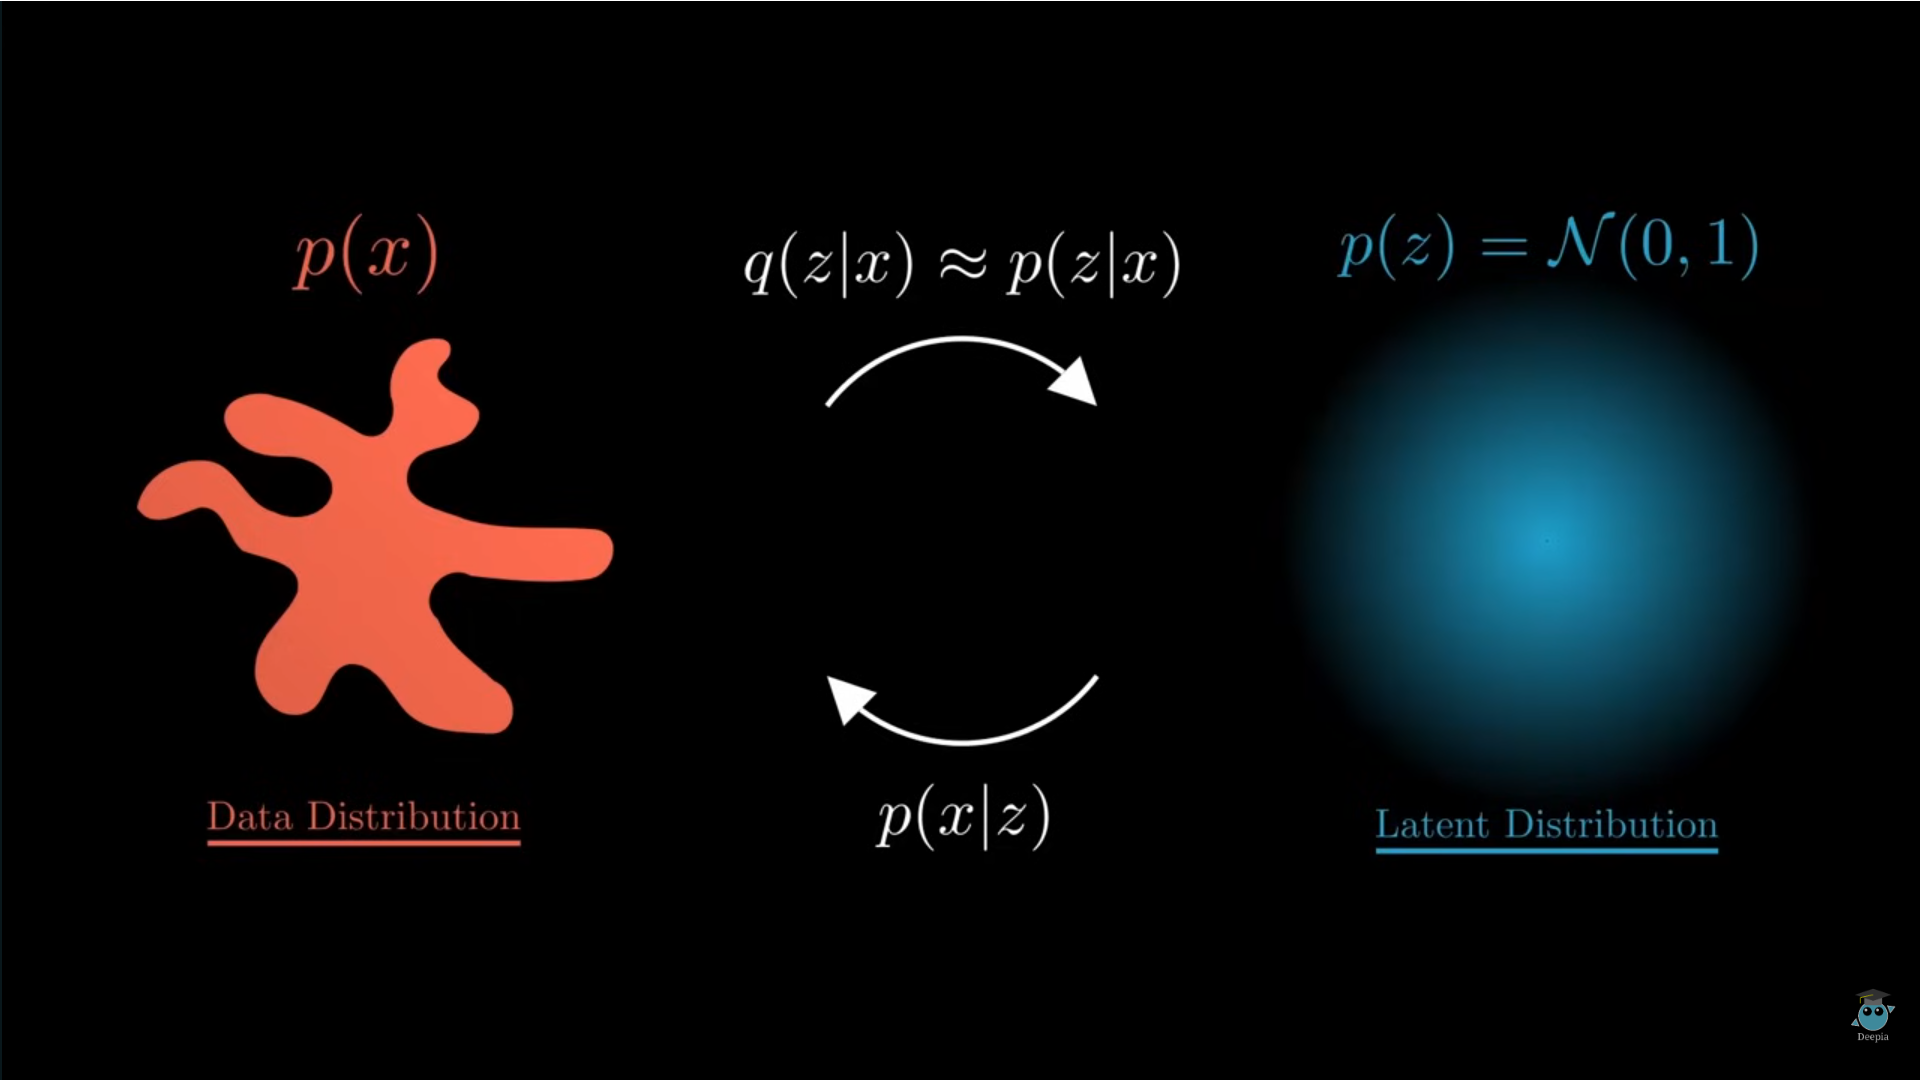
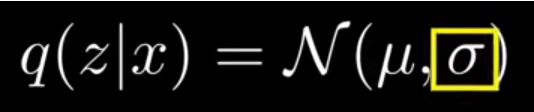       
            
            This Gaussian will have parameters  mu and sigma, which we need to learn , which is an optimization process, also usually known as variational bayes. 
            
            So we will train a deep encoder to estimate these  mu and sigma from the images.
            
            Then we will use decoder to reconstruct images from Latent variables that are sampled from approximate posterior. 
    
    2. Training VAE's
        a. ELBO => Using baye's formulae and some basic properties we can derive this training objective - below.  Which also called as ELBO.
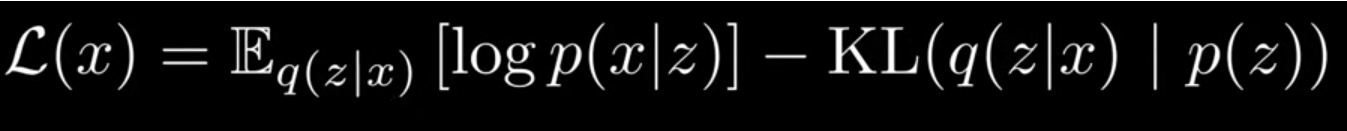
        
        b. First part of this equation is Data consistency term, 2nd part is regularization.
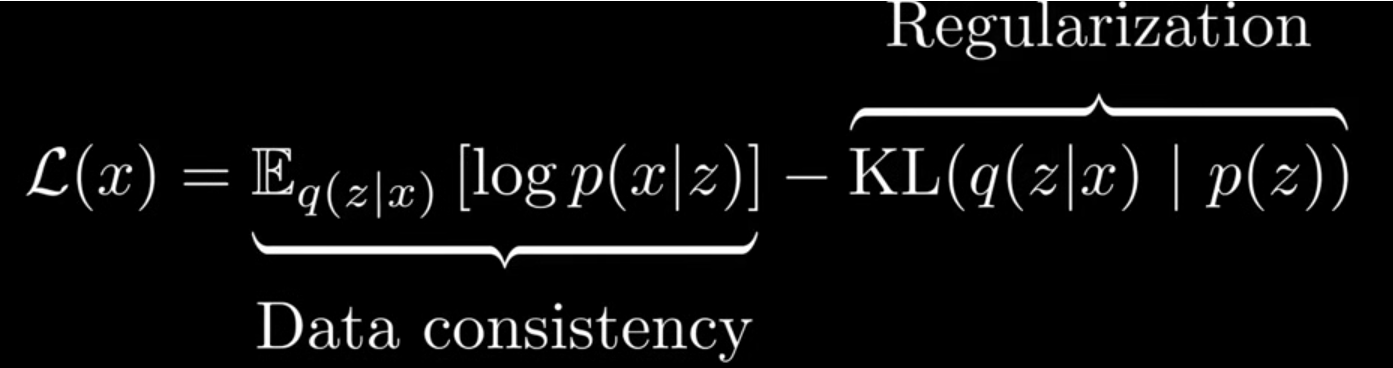

        c. Data consistency term simply measures, how well our model can reconstruct an image x from its encoded versions z. To ensure that z is taken from approximate posterior, we take a real image and simply encode it.  
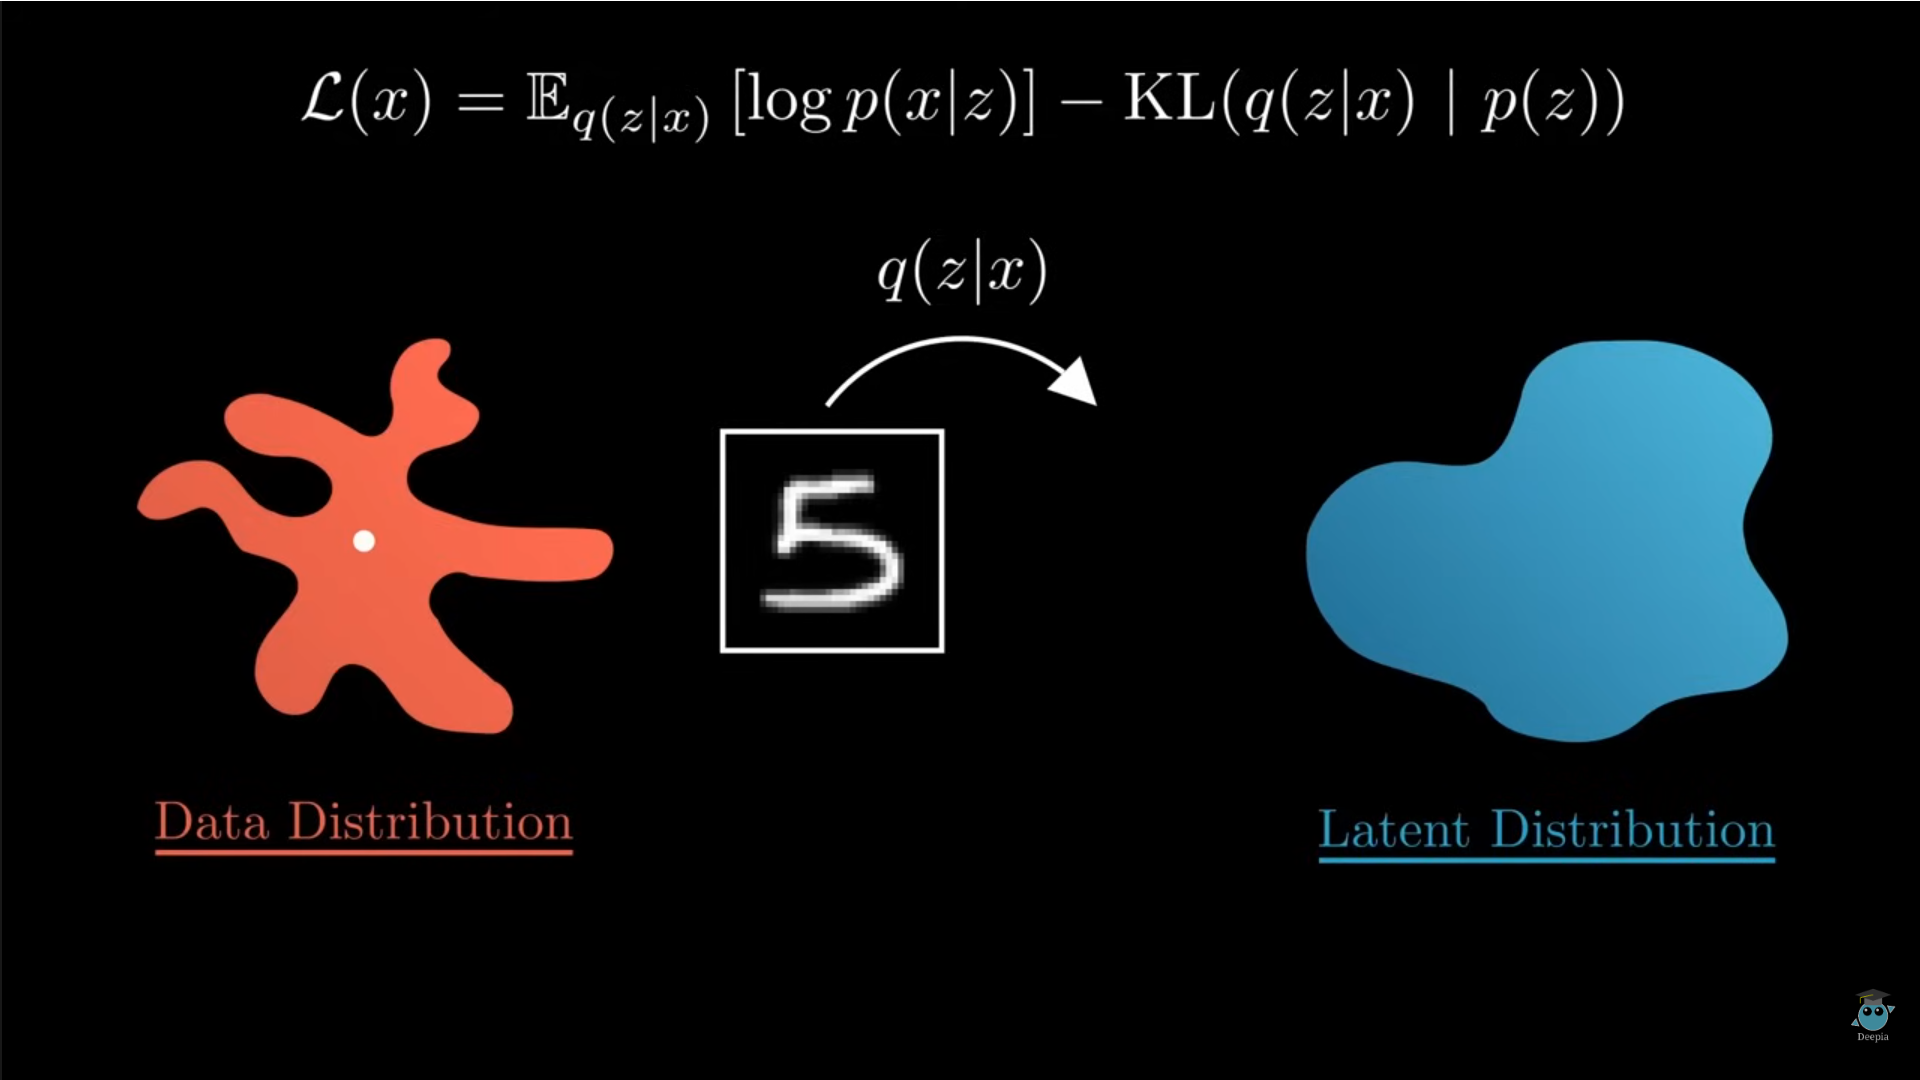

        So conviniently, - with all our assumpions, this likelihood term reduces, to a simple L2 reconstruction loss, 
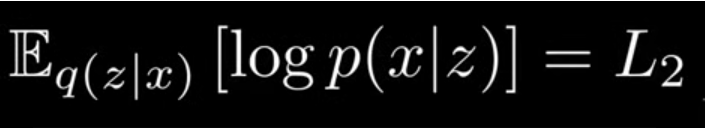     
        also known as the mean square error. So to estimate it, we simply take our latent and reconstruct it using decoder, then measure the L2 between reconstruction and original image(using MSE).
        d. Now Lets look at KL divergence part of the equation
            i. If you remember our previous video on latent space visualization, you know that the KL divergence is a kind of distance between two probability distributions, so this term measures how close our approximate posterior, is to prior distribution p(z). 
            ii. Since we chose p(z) as normal distribution, this means that when we optimize the ELBO, we constrain approximate posterior, to take shape of the normal distribution as well.
            iii. ELBO is  the training objective of our variational auto encoder, and it is designed to ensure that the generated samples come from our, original data distribution p(x). It can be thought of as regularized reconstruction loss and with first term representing the usual L2 loss and second term imposing normal distribution shape on our latent space.
            
    3. Practical 
        a. 1 Step => instead of mapping to a single point(like we did in Auto encoders),  Encoder converts the input   into a probability distribution(that we choose as Gaussian/Normal distribution) i.e  it converts input data as mean(mu) and variance(sigma).     
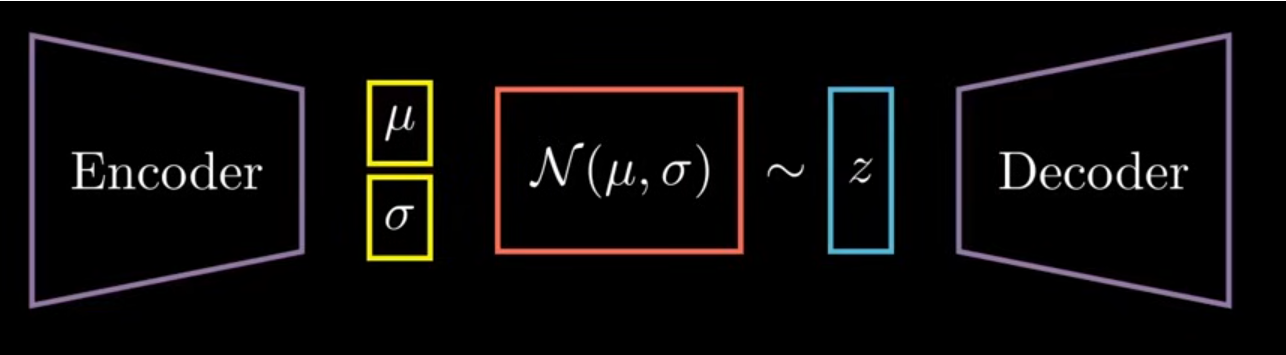
        
        This implies, instead of representing an image a single point in the latent space, its represented as Gaussian distribution.  
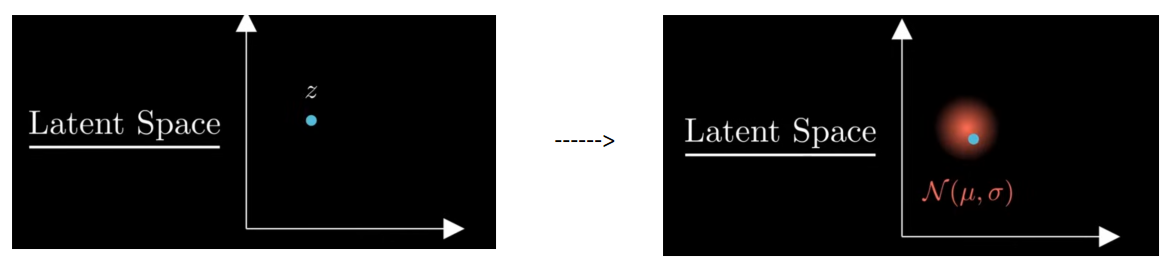

        b. 2nd Step => from this approximate posterior (gaussian distribution mentioned above) =>  we sample a point's at random , and decoder converts  sample points back into the input space, we can then compute the different parts of the ELBO loss and back propagate it through network. 
        
        c. Back propagation?
            - Can we really Backpropogate => backpropogating through sampling operation? Actually no.
            -  so reparametrization Trick
                □ Instead of sampling directly from the gaussian distribution, we introduce a random variable often called epsilon, to handle the randomness outside  of the network. 
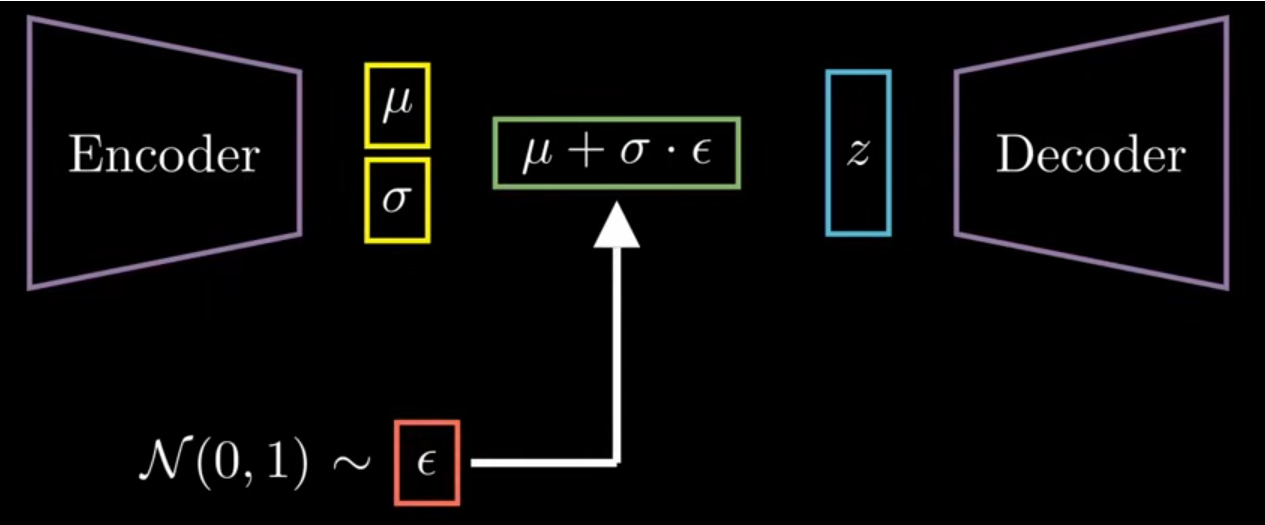
                
            - Steps =. 
        
            It is just as if we sample directly from posterior distribution.
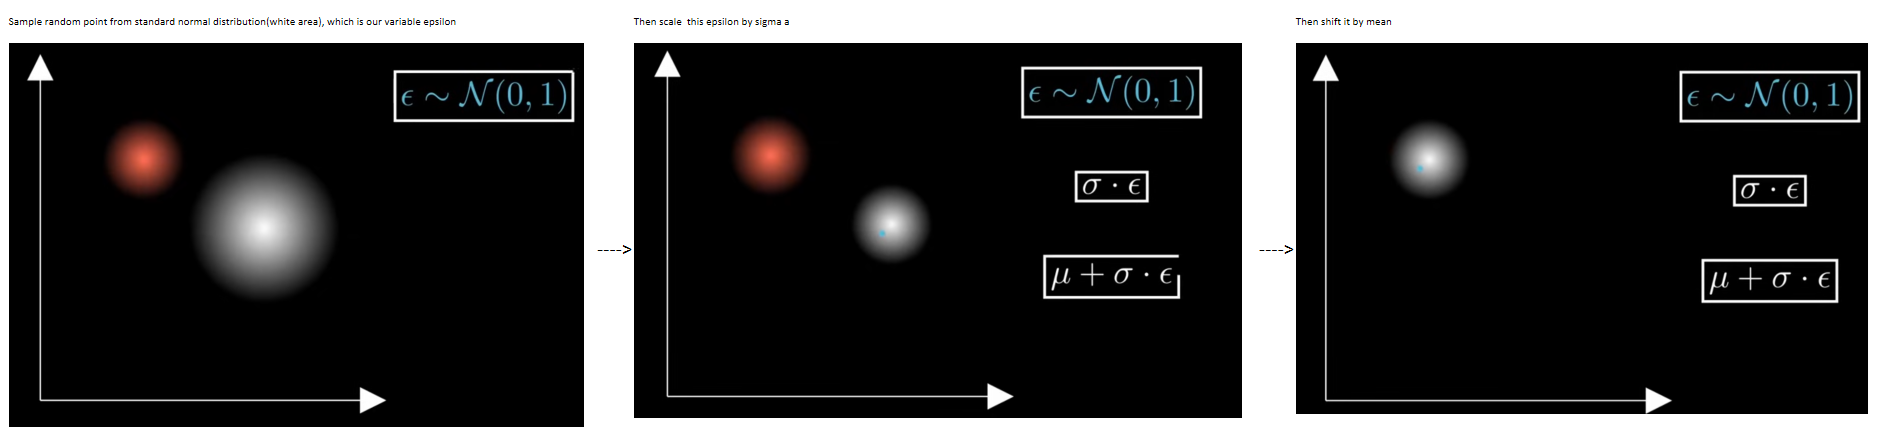
            Except that by using reparametrization trick.
            
            
            
            This will allow us to back propogate through entire network - enabling us to tgrain VAE end to end.
            
    4. Detailed steps
        
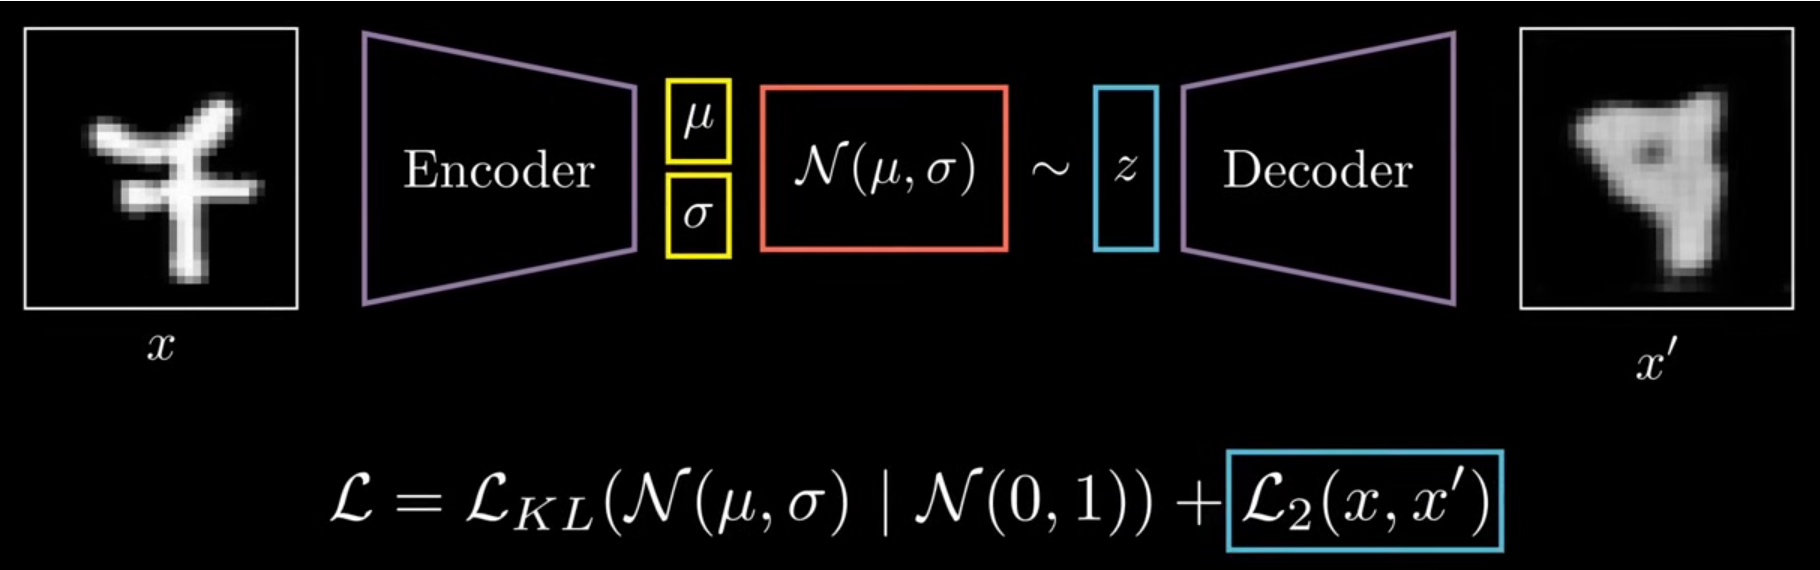     

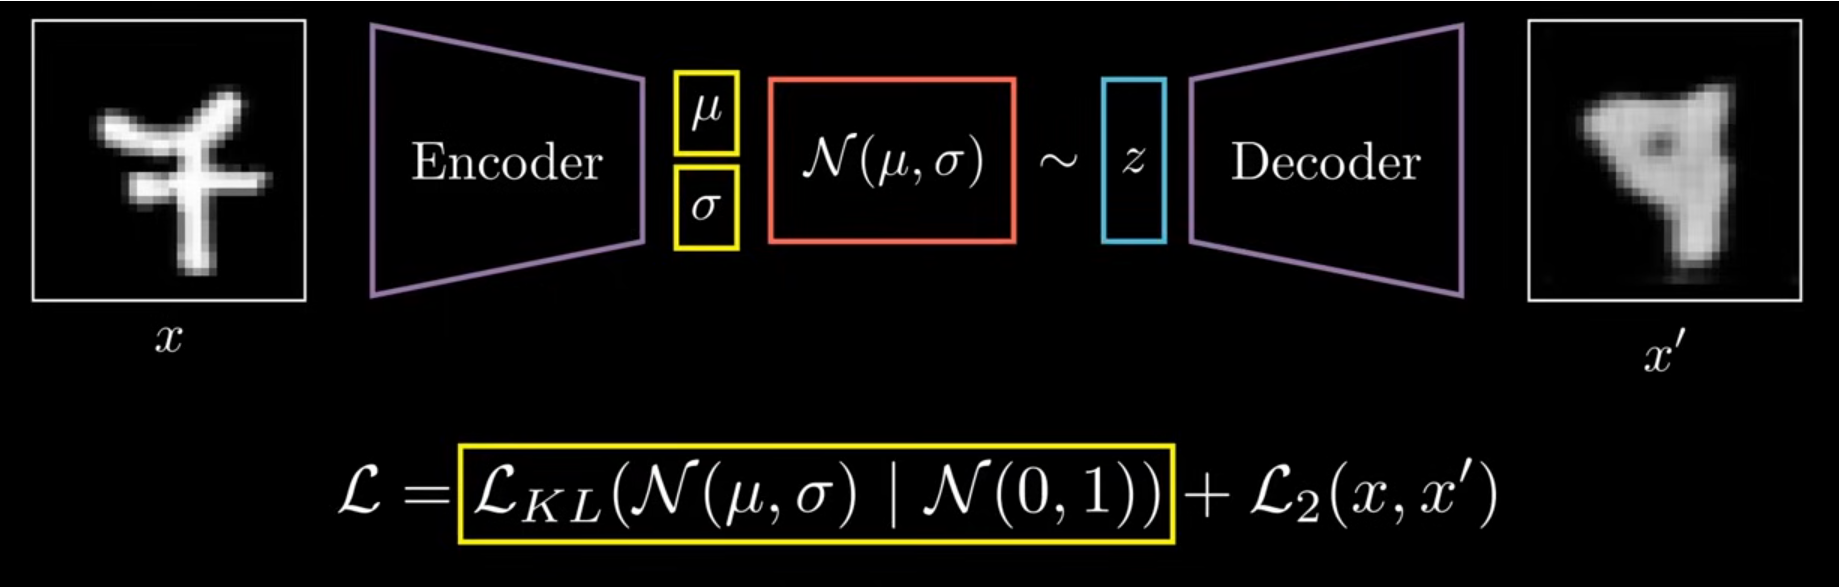
        
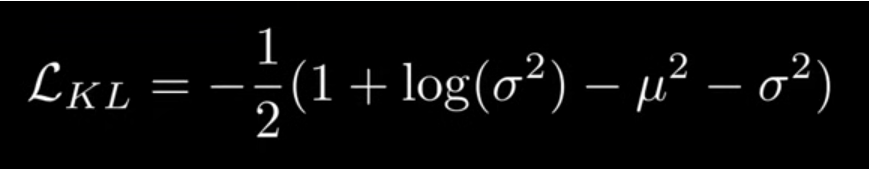
        
        
        
        
        
        
        
    5. Visualize how latent space evolves?
        
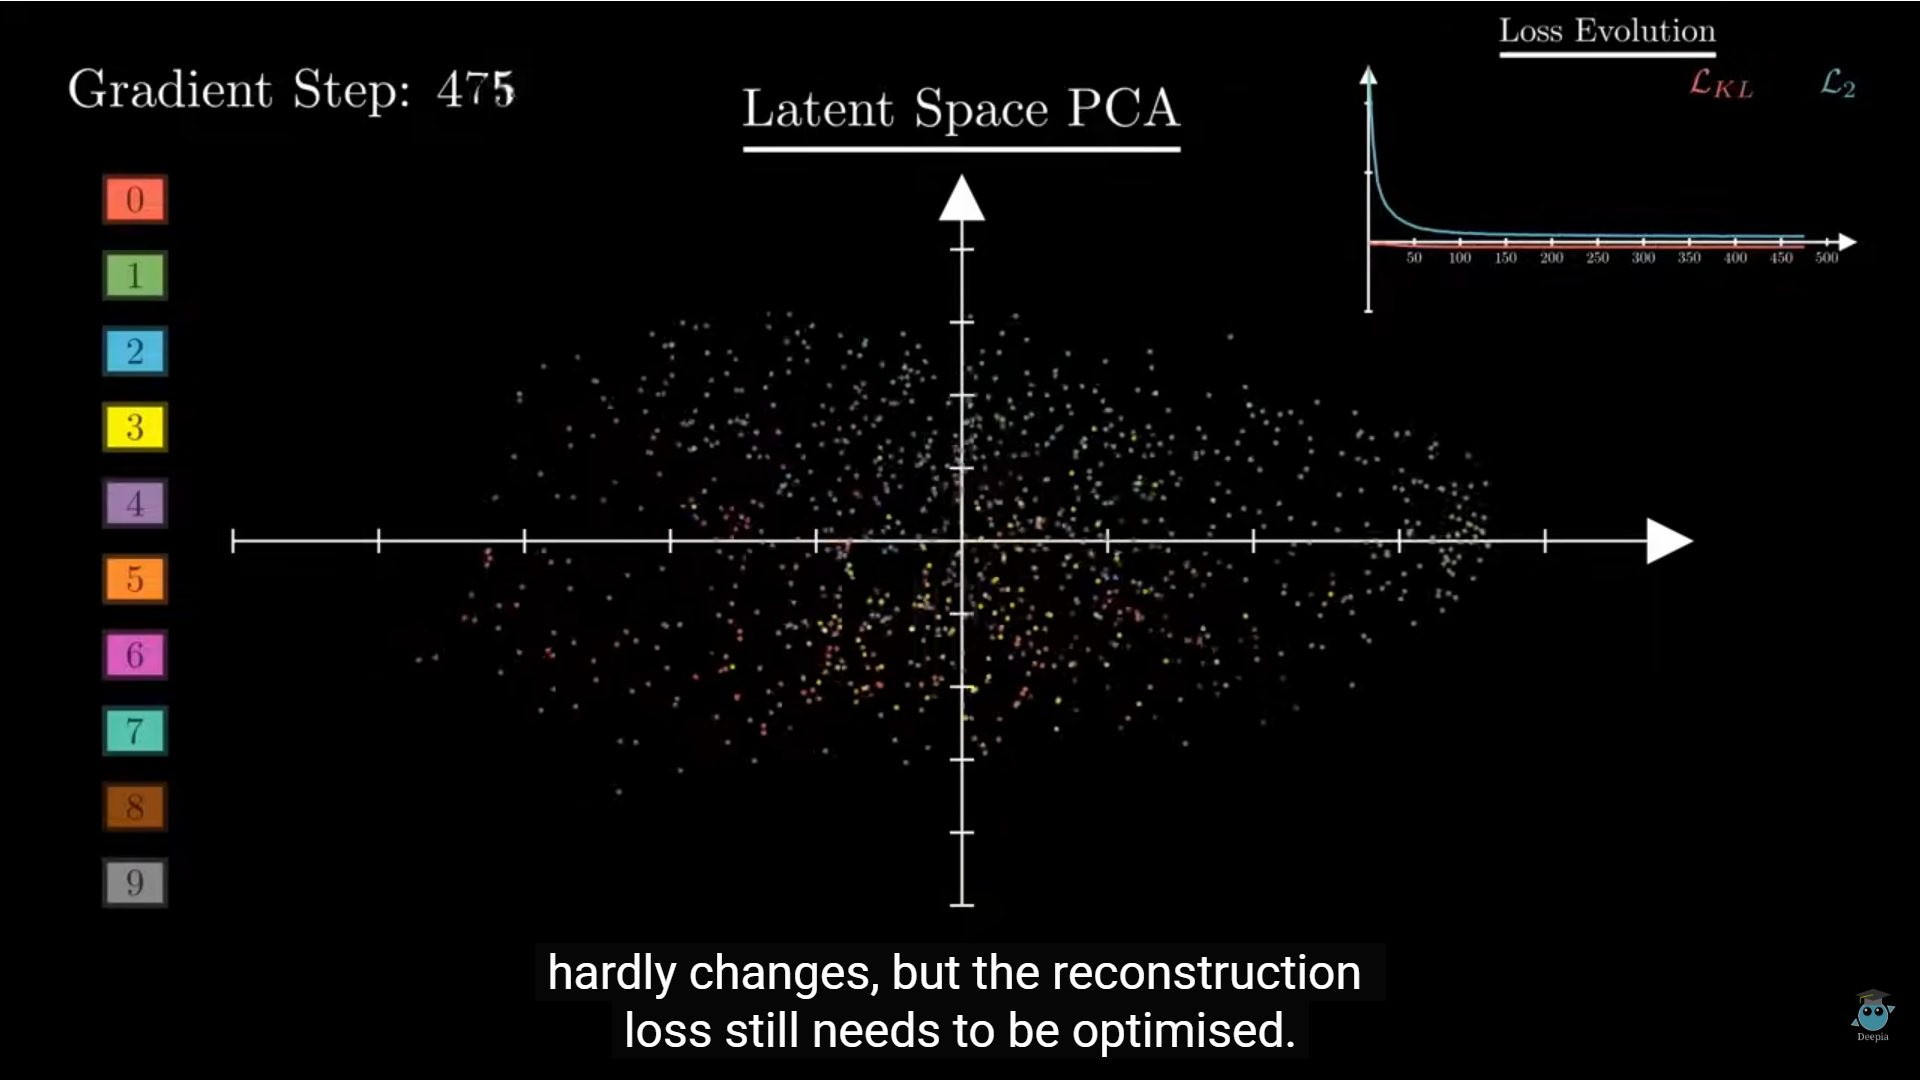
        
        
        After training complete
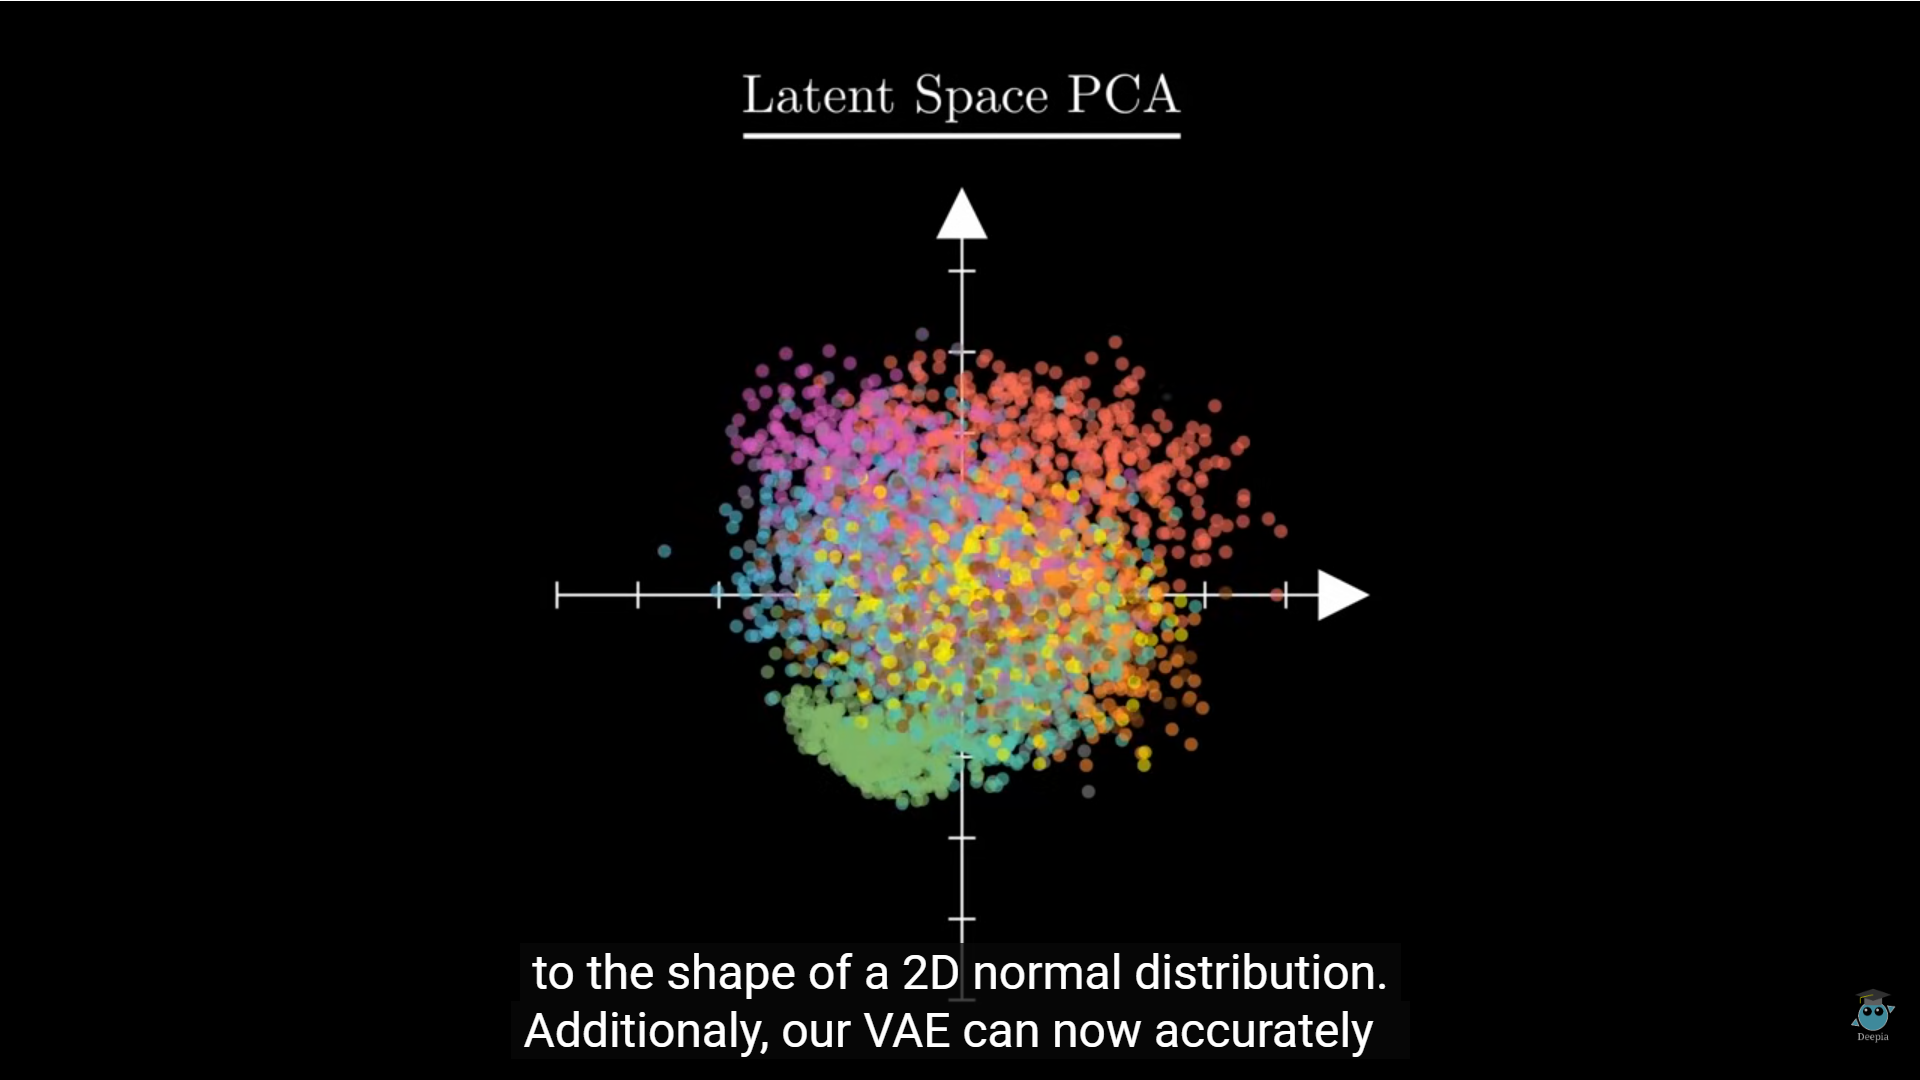

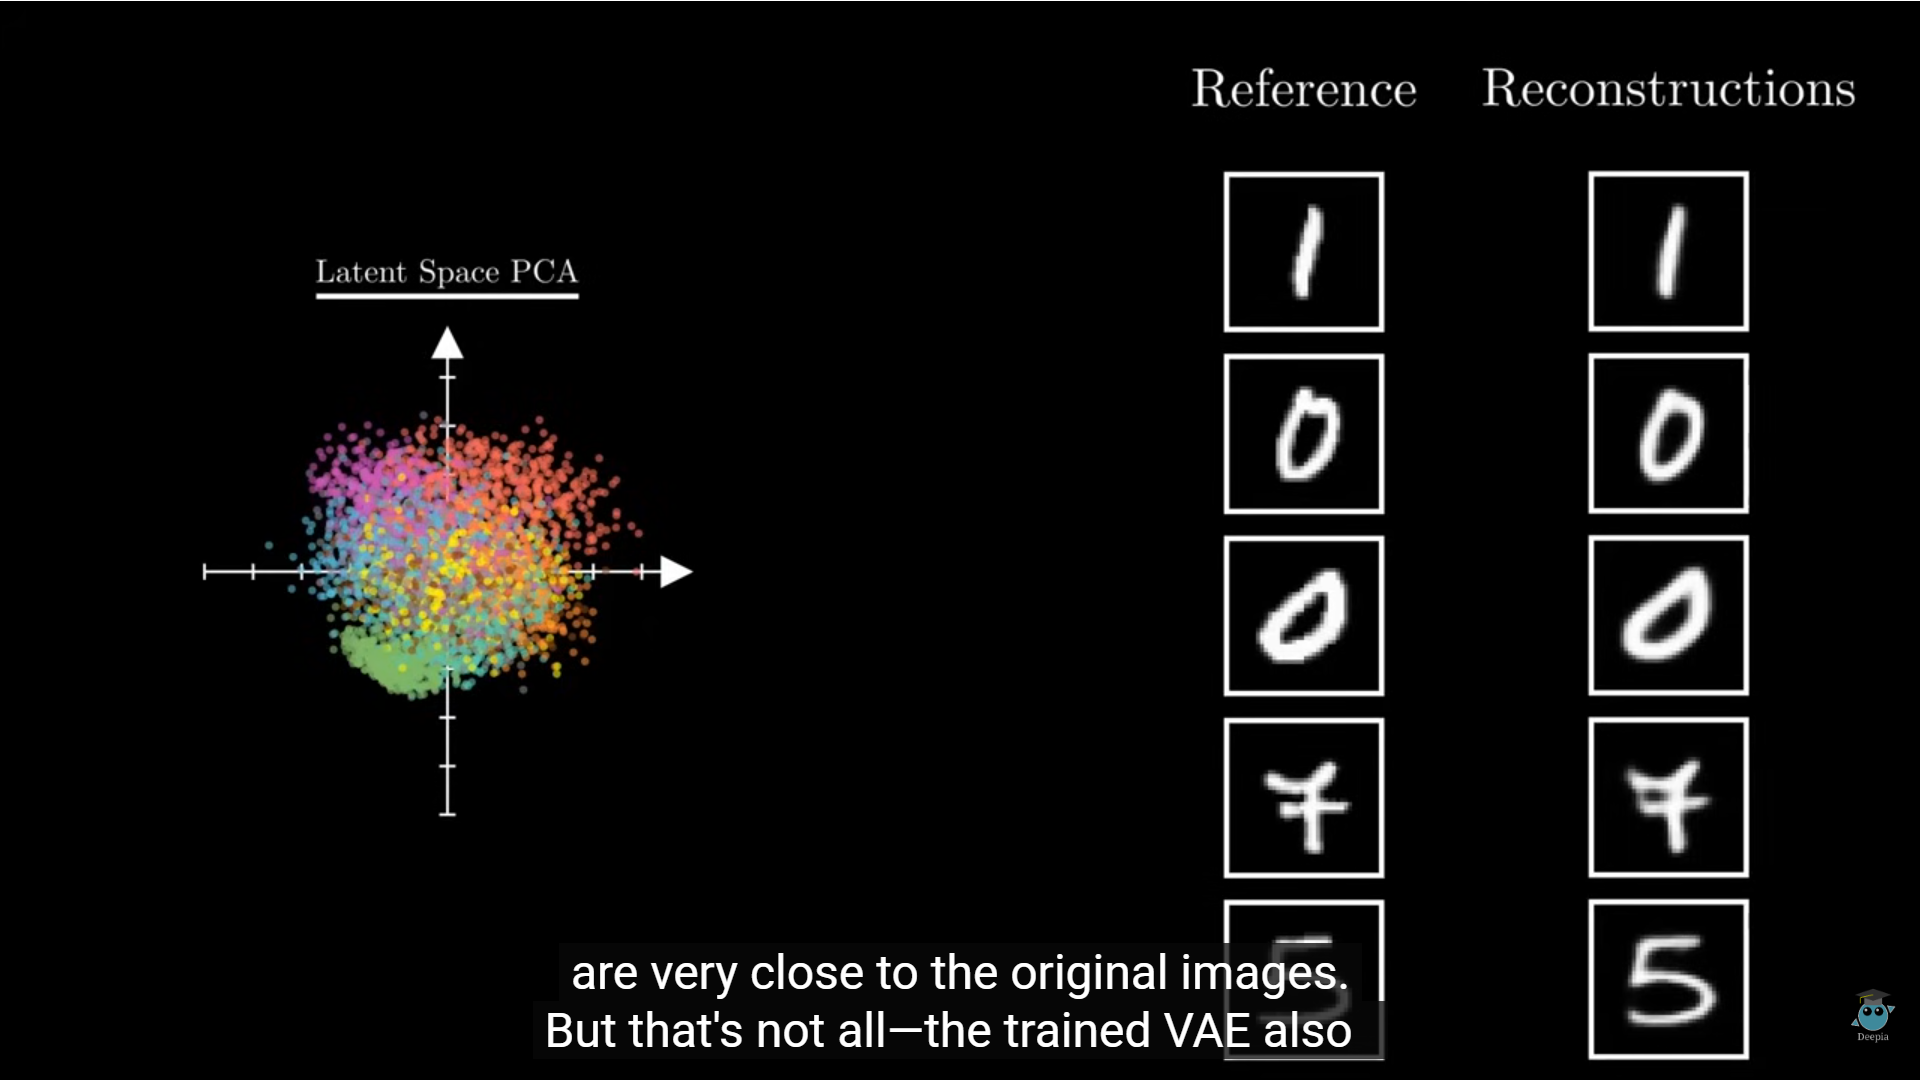        

        
    6. Limitations
        a. VAE's produce blurry images.
